<a href="https://colab.research.google.com/github/kayodedada16-rgb/ASSIGNMENT9-UNSUPERVISED-LEARNING/blob/main/ASSIGNMENT_9UNSUPERVISED_LEARNING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATASET SELECTION AND PREPROCESSING

In [1]:
# Step 1: Dataset Selection and Preprocessing
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Load Dataset (Replace this with pd.read_csv('your_dataset.csv') for Kaggle/UCI data)
raw_data = load_iris()
df = pd.DataFrame(raw_data.data, columns=raw_data.feature_names)

# Add a dummy categorical column to demonstrate one-hot encoding requirement
df['Category'] = np.random.choice(['Type_A', 'Type_B', 'Type_C'], size=len(df))

print("Original Data Shape:", df.shape)
display(df.head())

# 2. Handle Missing Values (if any)
# Drop or fill missing values
df = df.dropna()

# 3. One-Hot Encoding for Categorical Variables
df_encoded = pd.get_dummies(df, columns=['Category'], drop_first=True)

# 4. Feature Scaling / Normalization
# Scaling numerical features so distance-based algorithms work correctly
numerical_cols = raw_data.feature_names
scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

print("\nPreprocessed Data Shape:", df_encoded.shape)
display(df_encoded.head())

Original Data Shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Category
0,5.1,3.5,1.4,0.2,Type_B
1,4.9,3.0,1.4,0.2,Type_C
2,4.7,3.2,1.3,0.2,Type_B
3,4.6,3.1,1.5,0.2,Type_C
4,5.0,3.6,1.4,0.2,Type_C



Preprocessed Data Shape: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Category_Type_B,Category_Type_C
0,-0.900681,1.019004,-1.340227,-1.315444,True,False
1,-1.143017,-0.131979,-1.340227,-1.315444,False,True
2,-1.385353,0.328414,-1.397064,-1.315444,True,False
3,-1.506521,0.098217,-1.283389,-1.315444,False,True
4,-1.021849,1.249201,-1.340227,-1.315444,False,True


# CLUSTERING (K-MEANS & HIERARCHICAL)

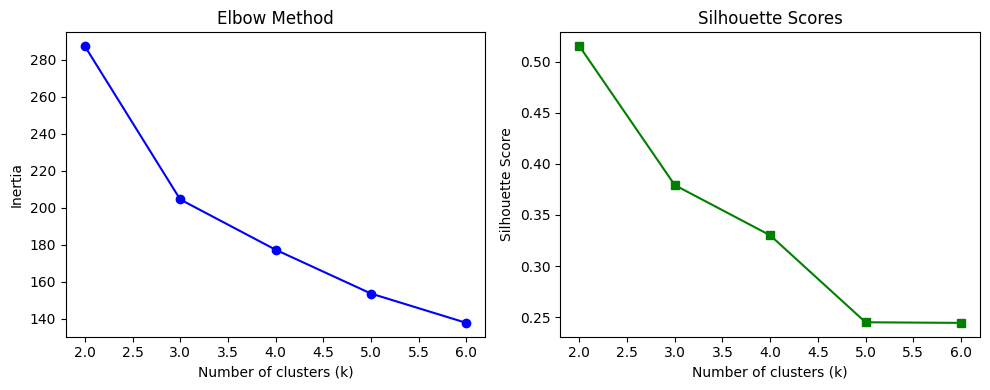

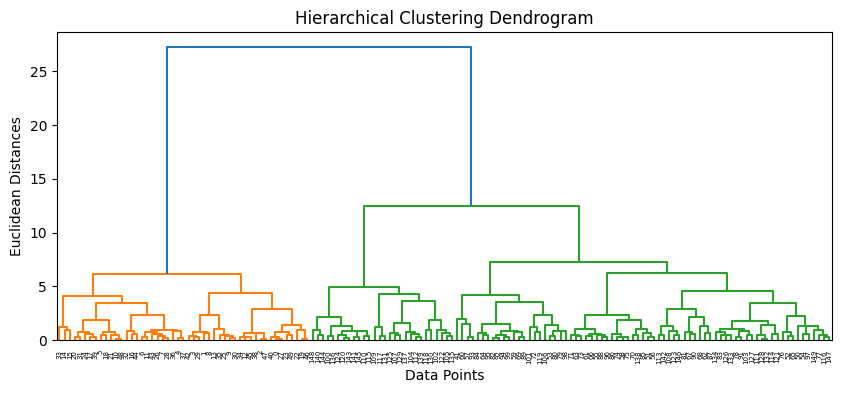

Cluster assignment completed successfully.


In [2]:
# Step 2: Clustering Techniques
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

X = df_encoded.values # Feature matrix

# --- Part A: K-Means & Elbow Method / Silhouette Score ---
inertia = []
silhouette_scores = []
K_range = range(2, 7)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

# Plot Elbow Method
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, marker='o', color='b')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='s', color='g')
plt.title('Silhouette Scores')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

# Fit Optimal K-Means (e.g., k=3 based on standard Iris/Mall data)
optimal_k = 3
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans_model.fit_predict(X)

# --- Part B: Hierarchical Clustering & Dendrogram ---
plt.figure(figsize=(10, 4))
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Euclidean Distances')
plt.show()

hierarchical_model = AgglomerativeClustering(n_clusters=optimal_k, metric='euclidean', linkage='ward')
df['Hierarchical_Cluster'] = hierarchical_model.fit_predict(X)

print("Cluster assignment completed successfully.")

# DIMENSIONALITY REDUCTION (PCA/t-SNE)

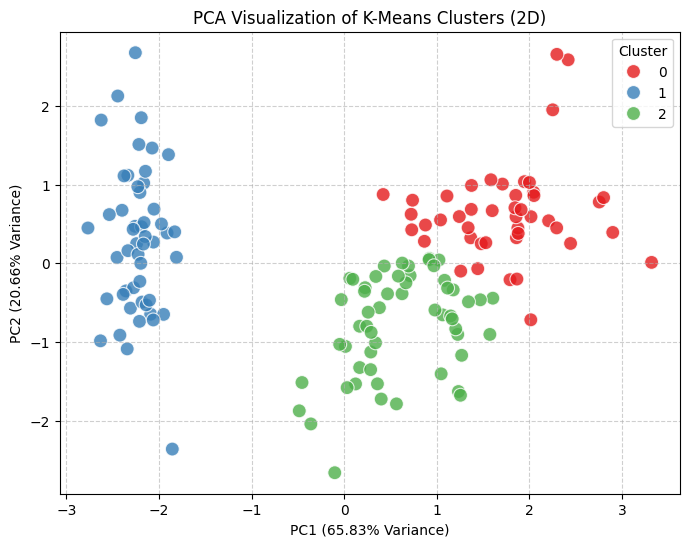

In [3]:
# Step 3: Dimensionality Reduction and Visualization
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Apply PCA (reducing to 2 components)
pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(X)

pca_df = pd.DataFrame(data=pca_transformed, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['KMeans_Cluster']

# Visualize PCA Clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Cluster',
    data=pca_df,
    palette='Set1',
    s=100,
    alpha=0.8
)
plt.title('PCA Visualization of K-Means Clusters (2D)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% Variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% Variance)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# MODEL EVALUATION

In [4]:
# Step 4: Model Evaluation
km_silhouette = silhouette_score(X, df['KMeans_Cluster'])
hc_silhouette = silhouette_score(X, df['Hierarchical_Cluster'])

evaluation_results = pd.DataFrame({
    'Model': ['K-Means Clustering', 'Hierarchical Clustering'],
    'Silhouette Score': [km_silhouette, hc_silhouette]
})

print("=== Model Evaluation Summary ===")
display(evaluation_results)

=== Model Evaluation Summary ===


,Model,Silhouette Score
0,K-Means Clustering,0.379238
1,Hierarchical Clustering,0.379647


Step 5: Deployment and Monitoring Strategy
​1. Hypothetical Production Scenario
​To transition the best-performing model (K-Means Clustering) from a development environment to production, we propose a Customer Segmentation & Targeted Marketing Pipeline for an e-commerce retail platform.

​Operational Flow: As new customer activity, transactional data, and demographic metrics are logged daily into the central data warehouse, an automated orchestration pipeline (e.g., Apache Airflow) triggers a batch scoring job every night at midnight.

​Actionable Output: The pipeline feeds the incoming customer vectors through the trained K-Means scaler and model, assigns each active customer a specific cluster label (e.g., High-Value Loyalist, Budget-Conscious Shopper, Occasional Browser), and updates the marketing CRM database. This allows marketing teams to deploy personalized email campaigns and dynamic discount structures the following morning.

​2. Potential Challenges in Deployment
​Deploying unsupervised machine learning models introduces distinct architectural and operational hurdles:

​Latency: While batch inference (running overnight) minimizes latency concerns, real-time clustering (e.g., categorizing a user live during a web browsing session) would require low-latency API endpoints built with FastAPI or Flask, demanding optimized model serialization (using Joblib or ONNX) to keep response times under 100 milliseconds.

​Scalability: As the user base scales from thousands to millions of records, memory overhead and distance computations increase. Scaling requires distributed computing frameworks like Apache Spark (PySpark.ml.clustering) to handle massive parallel batch scoring efficiently.

​Maintenance & Version Control: Unsupervised models lack explicit ground-truth labels, making bug tracking and dependency management complex. Ensuring environment parity between the Google Colab development notebook and the cloud production server (via Docker containers) is critical to prevent silent calculation discrepancies.

​3. Model Monitoring and Updating Strategies
​Because consumer behaviors and market trends shift over time, unsupervised clusters are prone to degradation:
​Data Drift & Feature Mean Tracking: Implement automated monitoring metrics (such as Population Stability Index or calculating Euclidean distance shifts between baseline training means and incoming daily data batches) to detect when incoming user demographics deviate significantly from the baseline distribution.
​Silhouette Score Tracking on Rolling Windows: Continuously evaluate the internal cohesion of newly assigned batches. A sharp drop in rolling silhouette scores indicates that the existing cluster boundaries are no longer cleanly separating the data groups.

​Automated Retraining Schedules:

Establish a policy where the clustering model is automatically retrained on a rolling quarterly window (or triggered dynamically if data drift breaches predefined alerting thresholds) to ensure clusters reflect contemporary user behavior patterns.